# Recycle Streams

**Prerequisites:** [00h_connecting_units](./00h_connecting_units_in_series.ipynb), [00i_parallel_bypass](./00i_parallel_and_bypass.ipynb)

**Learning Objectives:**
- Understand why recycles are essential in chemical processes
- See how recycles create circular dependencies
- Implement fixed-point iteration to solve recycle loops
- Learn about tear streams and convergence

---

## Why Recycle?

Many reactions don't go to completion in a single pass. Without recycle:
- **Ammonia synthesis:** ~15% conversion per pass → 85% of feed wasted!
- **Methanol synthesis:** ~10-15% per pass
- **Most equilibrium-limited reactions**

**Solution:** Separate unreacted material and recycle it back.

```
              ┌─────────────────────────────────┐
              │           Recycle               │
              ▼                                 │
    Feed ──►Mixer──►Reactor──►Separator──►Product
                                  │
                                  └──► (recycle)
```

This dramatically improves overall conversion!

## The Circular Dependency Problem

The recycle stream creates a **circular dependency**:

1. Mixer output depends on **recycle** (unknown)
2. Reactor output depends on mixer output
3. Separator output depends on reactor output
4. **Recycle** depends on separator output → back to step 1!

We can't solve this in one forward pass. We need **iteration**.

In [1]:
# Setup
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import optimistix as optx

from difflow import (CSTR, CSTRParams, Flash, FlashParams, 
                     make_stream, get_flows, combine_streams, IdealThermo, SpeciesData)
from difflow.units.flash import Mixer

W0000 00:00:1765973657.613961 13717535 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765973657.623407 13717535 service.cc:145] XLA service 0x600001b94c00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765973657.623418 13717535 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765973657.624342 13717535 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765973657.624349 13717535 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


In [2]:
# Define process: A (heavy) -> B (light)

species_data = {
    'A': SpeciesData(name='A', MW=100.0, Cp_coeffs=(100.0, 0, 0, 0),
                    Hvap_coeffs=(40000.0, 0.38, 500.0),
                    antoine_coeffs=(10.0, 2200.0, -40.0), Hf=0.0),
    'B': SpeciesData(name='B', MW=80.0, Cp_coeffs=(80.0, 0, 0, 0),
                    Hvap_coeffs=(32000.0, 0.38, 450.0),
                    antoine_coeffs=(10.0, 1600.0, -40.0), Hf=-50000.0),
}
thermo = IdealThermo(species_data)
species_order = ['A', 'B']

# Rate function
def rate_fn(C, T, params):
    return jnp.array([params['k'] * C['A']])

stoich = jnp.array([[-1.0], [1.0]])

# Create units
cstr_params = CSTRParams(
    V=jnp.array(2.0),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(0.3)},
    species_order=species_order,
)
reactor = CSTR(cstr_params, thermo=thermo, mode='isothermal')

flash_params = FlashParams(species_order=species_order)
flash = Flash(flash_params, thermo=thermo)

mixer = Mixer(species_order, thermo=thermo)

print("Process units created")

Process units created


## Fixed-Point Iteration

To solve the recycle loop:

1. **Guess** initial recycle: $R^{(0)}$
2. **Calculate** flowsheet with this guess → new recycle $R^{(1)}$
3. **Check** convergence: Is $R^{(1)} \approx R^{(0)}$?
4. If not, **update** guess and repeat

We're looking for a **fixed point**: $R^* = f(R^*)$

In [3]:
# Manual fixed-point iteration

def one_iteration(recycle, fresh_feed, T_reactor=350.0, T_flash=350.0, P_flash=50000.0, Q_vol=0.1):
    """
    One pass through the flowsheet.
    
    Returns the NEW recycle stream (liquid from flash).
    """
    # Mix fresh feed with recycle
    reactor_inlet = mixer(fresh_feed, recycle)
    
    # React
    reactor_out, _ = reactor(reactor_inlet, T_spec=T_reactor, volumetric_flow=Q_vol)
    
    # Separate at lower pressure for good vapor/liquid separation
    liquid, vapor, _ = flash(reactor_out, T=T_flash, P=P_flash)
    
    # Liquid is the new recycle
    return liquid, vapor

# Fresh feed
fresh_feed = make_stream({'A': 10.0, 'B': 0.0}, T=300.0, P=101325.0)

# Initial guess for recycle (start small)
recycle = make_stream({'A': 1.0, 'B': 0.1}, T=350.0, P=101325.0)

print("Fixed-Point Iteration")
print("=" * 70)
print(f"{'Iter':<6} {'Recycle A':<12} {'Recycle B':<12} {'Product B':<12} {'Change':<12}")
print("-" * 70)

history = []

for iteration in range(30):
    old_A = float(get_flows(recycle)['A'])
    old_B = float(get_flows(recycle)['B'])
    
    # One flowsheet pass
    new_recycle, product = one_iteration(recycle, fresh_feed)
    
    new_A = float(get_flows(new_recycle)['A'])
    new_B = float(get_flows(new_recycle)['B'])
    product_B = float(get_flows(product)['B'])
    
    change = max(abs(new_A - old_A), abs(new_B - old_B))
    history.append((new_A, new_B, product_B, change))
    
    print(f"{iteration+1:<6} {new_A:<12.4f} {new_B:<12.4f} {product_B:<12.4f} {change:<12.2e}")
    
    if change < 1e-6:
        print(f"\nConverged in {iteration+1} iterations!")
        break
    
    # Update with damping for stability
    damping = 0.5
    recycle = make_stream(
        {'A': old_A + damping*(new_A - old_A),
         'B': old_B + damping*(new_B - old_B)},
        T=350.0, P=101325.0
    )

Fixed-Point Iteration
Iter   Recycle A    Recycle B    Product B    Change      
----------------------------------------------------------------------


1      1.5468       4.0103       5.5182       3.91e+00    
2      1.5763       4.0868       7.6313       2.03e+00    


3      1.5930       4.1300       8.7337       1.06e+00    
4      1.6025       4.1545       9.3109       5.54e-01    


5      1.6078       4.1682       9.6141       2.91e-01    
6      1.6108       4.1760       9.7740       1.53e-01    


7      1.6125       4.1804       9.8587       8.10e-02    
8      1.6135       4.1829       9.9036       4.30e-02    


...

17     1.6147       4.1861       9.9552       1.68e-04    
18     1.6147       4.1861       9.9553       9.21e-05    


19     1.6147       4.1861       9.9554       5.06e-05    
20     1.6147       4.1861       9.9554       2.79e-05    


21     1.6147       4.1861       9.9554       1.54e-05    
22     1.6147       4.1861       9.9554       8.54e-06    


23     1.6147       4.1861       9.9554       4.74e-06    
24     1.6147       4.1861       9.9554       2.63e-06    


25     1.6147       4.1861       9.9554       1.46e-06    
26     1.6147       4.1861       9.9554       8.16e-07    

Converged in 26 iterations!


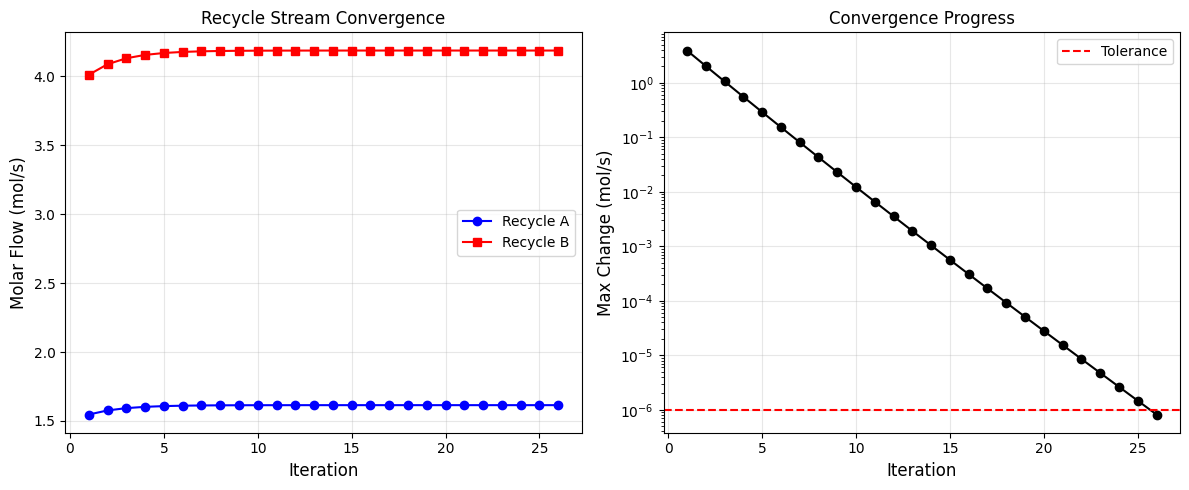

In [4]:
# Plot convergence

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Recycle flows
ax = axes[0]
iters = range(1, len(history)+1)
ax.plot(iters, [h[0] for h in history], 'b-o', label='Recycle A')
ax.plot(iters, [h[1] for h in history], 'r-s', label='Recycle B')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Molar Flow (mol/s)', fontsize=12)
ax.set_title('Recycle Stream Convergence', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Change (log scale)
ax = axes[1]
ax.semilogy(iters, [h[3] for h in history], 'k-o')
ax.axhline(y=1e-6, color='r', linestyle='--', label='Tolerance')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Max Change (mol/s)', fontsize=12)
ax.set_title('Convergence Progress', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()


## Using optimistix for Fixed-Point Iteration

The [optimistix](https://docs.kidger.site/optimistix/) library provides robust, JAX-native fixed-point solvers with automatic differentiation support.

In [5]:
def flowsheet_iteration(recycle_arr, args):
    """Flowsheet as a function of recycle array."""
    fresh_feed = args
    
    recycle = make_stream(
        {'A': recycle_arr[0], 'B': recycle_arr[1]},
        T=350.0, P=101325.0
    )
    
    new_recycle, _ = one_iteration(recycle, fresh_feed)
    
    return jnp.array([new_recycle['F_A'], new_recycle['F_B']])

# Solve using optimistix
initial_guess = jnp.array([1.0, 0.1])
solver = optx.FixedPointIteration(rtol=1e-8, atol=1e-8)
solution = optx.fixed_point(flowsheet_iteration, solver, initial_guess, args=fresh_feed, max_steps=100)
converged = solution.value

# Final evaluation
final_recycle = make_stream({'A': converged[0], 'B': converged[1]}, T=350.0, P=101325.0)
final_liquid, final_product = one_iteration(final_recycle, fresh_feed)

print("\nFinal Solution (optimistix solver)")
print("=" * 50)
print(f"Converged recycle: A = {float(converged[0]):.4f}, B = {float(converged[1]):.4f} mol/s")
print(f"Product B: {float(get_flows(final_product)['B']):.4f} mol/s")
print(f"")
print(f"Process Performance:")
print(f"  Feed A: 10.0 mol/s")
print(f"  Product B: {float(get_flows(final_product)['B']):.4f} mol/s")
print(f"  Overall yield: {float(get_flows(final_product)['B'])/10.0*100:.1f}%")


Final Solution (optimistix solver)
Converged recycle: A = 1.6147, B = 4.1861 mol/s
Product B: 9.9554 mol/s

Process Performance:
  Feed A: 10.0 mol/s
  Product B: 9.9554 mol/s
  Overall yield: 99.6%


## Impact of Recycle on Performance

Let's compare with and without recycle.

In [6]:
# Without recycle (single pass)
reactor_out_single, info_single = reactor(fresh_feed, T_spec=350.0, volumetric_flow=0.1)
liquid_single, vapor_single, _ = flash(reactor_out_single, T=350.0, P=50000.0)

print("Comparison: With vs Without Recycle")
print("=" * 50)
print(f"")
print(f"{'Metric':<25} {'Single Pass':<15} {'With Recycle':<15}")
print("-" * 55)
print(f"{'Reactor conversion':<25} {float(info_single['conversion']['A'])*100:<15.1f} {'(per-pass)':<15}")
print(f"{'Product B (mol/s)':<25} {float(get_flows(vapor_single)['B']):<15.4f} {float(get_flows(final_product)['B']):<15.4f}")
print(f"{'Waste A (mol/s)':<25} {float(get_flows(liquid_single)['A']):<15.4f} {float(get_flows(final_liquid)['A']):<15.4f}")
print(f"{'Overall yield (%)':<25} {float(get_flows(vapor_single)['B'])/10*100:<15.1f} {float(get_flows(final_product)['B'])/10*100:<15.1f}")
print(f"")
print(f"Per-pass conversion is lower with recycle because inlet is diluted,")
print(f"but overall yield is MUCH higher due to multiple passes!")

Comparison: With vs Without Recycle

Metric                    Single Pass     With Recycle   
-------------------------------------------------------
Reactor conversion        85.7            (per-pass)     
Product B (mol/s)         4.9245          9.9554         
Waste A (mol/s)           1.4066          1.6147         
Overall yield (%)         49.2            99.6           

Per-pass conversion is lower with recycle because inlet is diluted,
but overall yield is MUCH higher due to multiple passes!


## Damping and Convergence

**Damping factor** controls how much of the new value we use:

$$R^{(n+1)} = R^{(n)} + \alpha (R^{new} - R^{(n)})$$

- $\alpha = 1$: Full update (fastest if stable)
- $\alpha < 1$: Damped update (more stable but slower)
- $\alpha \to 0$: Almost no update (very slow)

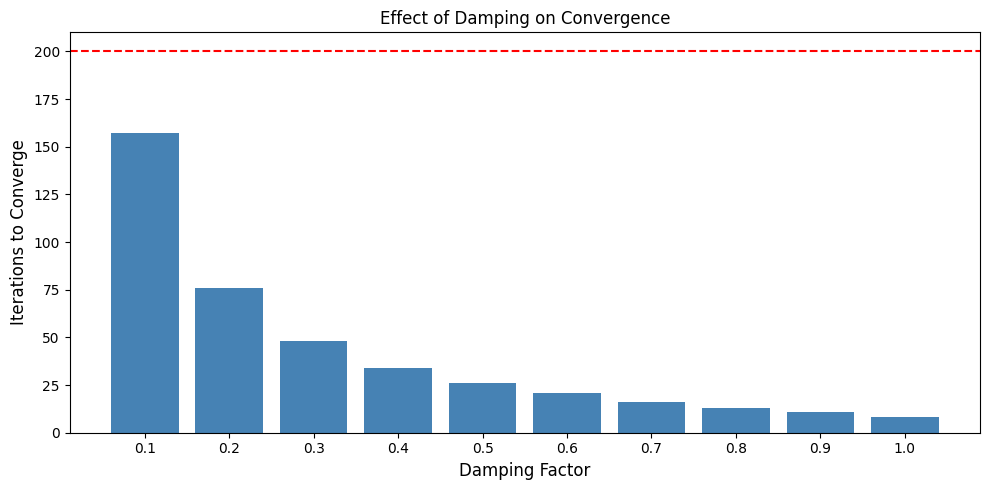

In [7]:
# Effect of damping on convergence

def count_iterations(damping, tol=1e-6):
    recycle = make_stream({'A': 1.0, 'B': 0.1}, T=350.0, P=101325.0)
    
    for iteration in range(200):
        old_A = float(get_flows(recycle)['A'])
        old_B = float(get_flows(recycle)['B'])
        
        new_recycle, _ = one_iteration(recycle, fresh_feed)
        
        new_A = float(get_flows(new_recycle)['A'])
        new_B = float(get_flows(new_recycle)['B'])
        
        change = max(abs(new_A - old_A), abs(new_B - old_B))
        
        if change < tol:
            return iteration + 1
        
        recycle = make_stream(
            {'A': old_A + damping*(new_A - old_A),
             'B': old_B + damping*(new_B - old_B)},
            T=350.0, P=101325.0
        )
    
    return 200  # Did not converge

dampings = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
iters = [count_iterations(d) for d in dampings]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(d) for d in dampings], iters, color='steelblue')
ax.set_xlabel('Damping Factor', fontsize=12)
ax.set_ylabel('Iterations to Converge', fontsize=12)
ax.set_title('Effect of Damping on Convergence', fontsize=12)
ax.axhline(y=200, color='r', linestyle='--', label='Did not converge')
plt.tight_layout()


## Try It Yourself!

### Exercise 1: Purge Stream
Add a **purge** stream that removes 5% of the recycle to prevent accumulation of inerts. How does this affect yield?

### Exercise 2: Multiple Recycles
Add a second flash drum that further separates the liquid stream. Can you improve yield?

### Exercise 3: Recycle Ratio
Define recycle ratio = (recycle flow)/(fresh feed flow). Plot yield vs recycle ratio.

---

## Key Takeaways

1. **Recycles improve yield** by giving unreacted material more chances to react
2. **Circular dependencies** require iterative solution
3. **Fixed-point iteration:** Guess → Calculate → Check → Update
4. **Damping** improves stability at the cost of speed
5. **Tear streams:** The streams we "guess" to break the cycle

---

## Next Steps

In the final notebook (**[00k: Why Differentiable Flowsheets?](./00k_why_differentiable_flowsheets.ipynb)**), we'll discover:
- Why gradients through flowsheets are powerful
- How difflow differentiates through recycle iterations
- Applications: optimization, sensitivity, uncertainty